In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os
import re
import joblib
import ast

In [3]:
def merge_cleaned_datasets(flat_path, house_path, indepedent_builder_floor_path, shuffle=True):
        
        
        flats_df = pd.read_csv(flat_path)
        houses_df = pd.read_csv(house_path)
        indepedent_builder_floor_df = pd.read_csv(indepedent_builder_floor_path)



        flats_df["property_type"] = "Flat"
        houses_df["property_type"] = "Independent House"
        indepedent_builder_floor_df["property_type"] = "Independent Builder Floor"


        merged_df = pd.concat([flats_df, houses_df, indepedent_builder_floor_df], ignore_index=True, sort=False)

        if shuffle:
            merged_df = merged_df.sample(frac=1, random_state=42).reset_index(drop=True)

        return merged_df

In [4]:
merged_df = merge_cleaned_datasets(
    "../../data/data_cleaning/cleaned_residential_apartment.csv",
    "../../data/data_cleaning/cleaned_independent_houses.csv",
    "../../data/data_cleaning/cleaned_independent_builder_floor.csv"
)

In [5]:
merged_df.shape

(5974, 18)

In [6]:
merged_df.sample(30)

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,additional_room,floor_info,facing,property_age,furnishing_details,features,nearby_location,property_type
2232,"2 Bedroom House in Sector 95A, Gurgaon","sector 95a, gurgaon",1.11,91735,121 sqft (11.24 sqm) Plot Area | 860 sqft (79....,N82052584,https://www.99acres.com/2-bhk-bedroom-independ...,2,2,2,study room,4 Floors,not available,0 to 1 Year Old,"['2 AC', 'No Bed', 'No Chimney', 'No Curtains'...",NaN,[],Independent House
5132,"3 BHK Flat in Sector 102, Gurgaon",conscient heritage max,2.64,13594,"1,942 sqft (180 sqm) Super Built-up Area",I84867524,https://www.99acres.com/3-bhk-bedroom-apartmen...,3,4,3+,"servant room,pooja room",4th of 25 Floors,north-east,1 to 5 Year Old,"['3 Wardrobe', '6 Fan', '1 Exhaust Fan', '4 Ge...","['Security / Fire Alarm', 'Feng Shui / Vaastu ...","['Holiday Inn Gurgaon Nh8', 'Millennium City C...",Flat
4763,"7 Bedroom House in DLF Phase 2, Gurgaon","dlf phase 2, gurgaon",12.00,44444,2700 sqft (250.84 sqm) Plot Area,Z84137782,https://www.99acres.com/7-bhk-bedroom-independ...,7,8,2,"pooja room,study room,others,servant room",3 Floors,east,1 to 5 Year Old,"['18 Fan', '1 Exhaust Fan', '8 Geyser', '1 Sto...","['Feng Shui / Vaastu Compliant', 'Private Gard...","['Deutsche bank', 'Religare Wellness', 'Darpan...",Independent House
5122,"4 Bedroom House in Sector 103, Gurgaon",satya the hermitage,4.25,9042,4700 sqft (436.64 sqm) Built-up Area,Z67904052,https://www.99acres.com/4-bhk-bedroom-independ...,4,5,0,not available,12 Floors,east,5 to 10 Year Old,NaN,"['Private Garden / Terrace', 'Maintenance Staf...","['S N International School', 'Gurgaon Railway ...",Independent House
133,"3 Bedroom House in Sector 49, Gurgaon",eros rosewood city,4.50,32680,1377 sqft (127.93 sqm) Plot Area,V81604971,https://www.99acres.com/3-bhk-bedroom-independ...,3,3,1,not available,2 Floors,not available,5 to 10 Year Old,[],NaN,"['Silver Oak Universal', 'Leelavati Hospital',...",Independent House
2740,"5 Bedroom House in Greenwood City, Gurgaon","greenwood city, gurgaon",8.35,11283,7400 sqft (687.48 sqm) Built-up Area | 6800 sq...,O82083912,https://www.99acres.com/5-bhk-bedroom-independ...,5,6,3,"store room,pooja room,servant room",3 Floors,north-east,1 to 5 Year Old,"['1 Water Purifier', '15 Fan', '1 Exhaust Fan'...","['Centrally Air Conditioned', 'Water purifier'...","['Citi bank ATM', 'Fortis Memorial Research In...",Independent House
2845,"4 BHK Flat in Sector 72, Gurgaon",tata primanti,8.50,18888,"4,500 sqft (418 sqm) Super Built-up Area",V83344704,https://www.99acres.com/4-bhk-bedroom-apartmen...,4,5,3+,"store room,servant room",2nd of 4 Floors,east,5 to 10 Year Old,"['1 Water Purifier', '9 Fan', '1 Fridge', '1 E...","['Centrally Air Conditioned', 'Water purifier'...","['RBSM Public school', 'Gurgaon Old Railway Ro...",Flat
2914,"3 BHK Flat in Sector 82A, Gurgaon",dlf the primus,2.85,15842,"1,799 sqft (167 sqm) Super Built-up Area",Y84673430,https://www.99acres.com/3-bhk-bedroom-apartmen...,3,3,3+,others,10th of 32 Floors,north,5 to 10 Year Old,"['3 Wardrobe', '1 Chimney', '5 AC', '1 Modular...","['Security / Fire Alarm', 'Power Back-up', 'Fe...","['Miracles Apollo Hospital', 'Singhania Univer...",Flat
1314,"6 Bedroom House in Sector 63A, Gurgaon",anant raj estates,11.50,42593,2700 sqft (250.84 sqm) Plot Area,U83906948,https://www.99acres.com/6-bhk-bedroom-independ...,6,7,3+,"pooja room,study room,servant room",3 Floors,north,0 to 1 Year Old,"['1 Water Purifier', '13 Fan', '1 Exhaust Fan'...","['Water purifier', 'Centrally Air Conditioned'...","['Gurgaon Railway Station', 'Sohna Road (NH 24...",Independent House
60,"2 BHK Flat in Sector 65, Gurgaon",emaar mgf emerald estate,1.99,19509,"1,020 sqft (95 sqm) Super Built-up Area",Q83654292,https://www.99acres.com/2-bhk-bedroom-apartmen...,2,2,2,study room,5th of 13 Floors,east,1 to 5 Year Old,"['2 Wardrobe', '4 Fan', '1 Exhaust Fan', '2 Ge...","['Power Back-up', 'Feng Shui

In [7]:
merged_df.isnull().sum()

property_name           0
society                 0
price_in_cr             0
price_per_sqft          0
areawithtype            0
property_id             0
link                    0
bedrooms                0
bathrooms               0
balcony                 0
additional_room         0
floor_info            104
facing                  0
property_age          110
furnishing_details    822
features              376
nearby_location         0
property_type           0
dtype: int64

In [8]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5974 entries, 0 to 5973
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   property_name       5974 non-null   object 
 1   society             5974 non-null   object 
 2   price_in_cr         5974 non-null   float64
 3   price_per_sqft      5974 non-null   int64  
 4   areawithtype        5974 non-null   object 
 5   property_id         5974 non-null   object 
 6   link                5974 non-null   object 
 7   bedrooms            5974 non-null   int64  
 8   bathrooms           5974 non-null   int64  
 9   balcony             5974 non-null   object 
 10  additional_room     5974 non-null   object 
 11  floor_info          5870 non-null   object 
 12  facing              5974 non-null   object 
 13  property_age        5864 non-null   object 
 14  furnishing_details  5152 non-null   object 
 15  features            5598 non-null   object 
 16  nearby

In [9]:
merged_df.duplicated().sum()

np.int64(0)

#### 1. Feature Engineering

In [10]:
merged_df_copy = merged_df.copy()

#### 1. Sector

In [11]:
fe_df =(merged_df.assign(
            sector = lambda df_: df_['property_name']
                        .str
                        .split('in')
                        .str
                        .get(1)
                        .str
                        .replace('Gurgaon', '')
                        .str
                        .replace("-","")
                        .str
                        .replace(",","")
                        .str
                        .strip()
                        .str
                        .lower()  
))

In [12]:
fe_df['sector'].value_counts()

sector
palam vihar              182
sector 102               180
sector 65                175
sector 81                162
dlf phase 1              153
                        ... 
railyway road gurgaon      1
basai village              1
khandsha                   1
shanti kunj                1
block a surya vihar        1
Name: count, Length: 350, dtype: int64

In [13]:
fe_df =(merged_df
    .assign( 
                sector = lambda df_: df_['property_name']
                        .str
                        .split('in')
                        .str
                        .get(1)
                        .str
                        .replace('Gurgaon', '')
                        .str
                        .replace("-","")
                        .str
                        .replace(",","")
                        .str
                        .strip()
                        .str
                        .lower()                        
            )
)

In [14]:
fe_df['sector'].unique().tolist()

['sushant lok phase 1',
 'sohna road',
 'sector 72',
 'dlf phase 4',
 'behrampur',
 'sector 102',
 'sector33 sohna',
 'sector 45',
 'sector 90',
 'sohna',
 'malibu town',
 'sector 4',
 'sector 46',
 'south city 1',
 'sector 37d',
 'a block sushant lok phase 1',
 'sector 43',
 'dlf phase 2',
 'sector 67',
 'block q south city 1',
 'dlf phase 1',
 'sector 65',
 'sector 52',
 'sector 106',
 'sector 10a',
 'sector 89',
 'sector 54',
 'sector 23',
 'sector 104',
 'block g rajendra park',
 'sector 49',
 'sector 108',
 'block a greenwood city',
 'sector 81',
 'sushant lok 2sector 55',
 'sector 85',
 'sector 10',
 'sector 56',
 'block c2 sector 3',
 'sector 77',
 'patel nagar',
 'sushant lok phase 2',
 'sector 70a',
 'sector 7',
 'sector 89 a',
 'sector 82',
 'sector35 sohna',
 'block d rajendra park',
 'sector 91',
 'new palam vihar',
 'saraswati vihar',
 'sector 57',
 'sector 83',
 'sector 41',
 'sector 48',
 'sector 112',
 'palam vihar',
 'sector 28',
 'sector 67a',
 'sector 86',
 'sector 9

In [15]:
fe_df['sector'].nunique()

350

In [16]:
fe_df['sector'].value_counts().reset_index()

,sector,count
0,palam vihar,182
1,sector 102,180
2,sector 65,175
3,sector 81,162
4,dlf phase 1,153
...,...,...
345,railyway road gurgaon,1
346,basai village,1
347,khandsha,1
348,shanti kunj,1


Palam Vihar - Old Gurgaon - Sector 1, Sector 2, New Palam Vihar, Palam Vihar Extension - https://www.99acres.com/palam-vihar-gurgaon-overview-piffid

In [17]:
fe_df[fe_df['sector']=='hous']

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,additional_room,floor_info,facing,property_age,furnishing_details,features,nearby_location,property_type,sector
1842,"3 Bedroom House in Housing board colony,Sector...","housing board colony,sector 7 ext, gurgaon",0.75,7788,963 sqft (89.47 sqm) Plot Area,J84039884,https://www.99acres.com/3-bhk-bedroom-independ...,3,3,2,not available,2 Floors,not available,10+ Year Old,[],NaN,"['Kr Dental Hub', 'Pasricha Hospital and Mater...",Independent House,hous
1885,"4 Bedroom House in Housing board colony,Sector...","housing board colony,sector 7 ext, gurgaon",0.80,22222,360 sqft (33.45 sqm) Plot Area,M81914122,https://www.99acres.com/4-bhk-bedroom-independ...,4,2,3,"pooja room,study room",3 Floors,north-east,10+ Year Old,NaN,"['Feng Shui / Vaastu Compliant', 'Private Gard...","['Kr Dental Hub', 'Pasricha Hospital and Mater...",Independent House,hous
3122,"6 Bedroom House in Housing board colony,Sector...","housing board colony,sector 7 ext, gurgaon",0.65,18056,360 sqft (33.45 sqm) Plot Area,Y81786394,https://www.99acres.com/6-bhk-bedroom-independ...,6,3,3,study room,4 Floors,north-east,10+ Year Old,"['6 Wardrobe', '6 Fan', '1 Exhaust Fan', '3 Ge...","['Feng Shui / Vaastu Compliant', 'Private Gard...","['Kr Dental Hub', 'Pasricha Hospital and Mater...",Independent House,hous


In [18]:
fe_df[fe_df['sector']=='medicity']

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,additional_room,floor_info,facing,property_age,furnishing_details,features,nearby_location,property_type,sector
2697,"4 Bedroom House in Medicity, Gurgaon","medicity, gurgaon",9.0,61350,1467 sqft (136.29 sqm) Plot Area,P82891986,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,3+,others,13 Floors,north-east,1 to 5 Year Old,"['1 Wardrobe', '2 Fan', '1 Light', 'No AC', 'N...",['Maintenance Staff'],"['Wellness Eye Centre', 'Bar and restaurant', ...",Independent House,medicity


In [19]:
fe_df[fe_df['sector']=='pataudi']

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,additional_room,floor_info,facing,property_age,furnishing_details,features,nearby_location,property_type,sector
3340,"5 Bedroom House in Pataudi, Gurgaon","pataudi, gurgaon",3.20,17778,1800 sqft (167.23 sqm) Plot Area,R84748786,https://www.99acres.com/5-bhk-bedroom-independ...,5,4,2,"pooja room,study room,servant room,store room",2 Floors,north,1 to 5 Year Old,"['4 Bed', '3 Wardrobe', '3 Fan', '7 Light', '2...","['High Ceiling Height', 'Maintenance Staff', '...","['Shree Kailash Hospital', 'Dr. Chauhan Neeraj...",Independent House,pataudi
4532,"3 Bedroom House in Pataudi, Gurgaon","pataudi, gurgaon",0.25,25000,80 sqft (7.43 sqm) Plot Area,I84416748,https://www.99acres.com/3-bhk-bedroom-independ...,3,2,2,not available,NaN,not available,10+ Year Old,NaN,NaN,"['Dr. Kishore Rao Bhawan', 'Varma Dental and E...",Independent House,pataudi


In [20]:
fe_df[fe_df['sector']=='huda sector']

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,additional_room,floor_info,facing,property_age,furnishing_details,features,nearby_location,property_type,sector
2053,"7 Bedroom House in Huda Sector, Gurgaon","huda sector, gurgaon",10.0,35727,2799 sqft (260.04 sqm) Plot Area,H84345526,https://www.99acres.com/7-bhk-bedroom-independ...,7,8,3+,"pooja room,servant room,study room",3 Floors,north,5 to 10 Year Old,"['1 Water Purifier', '11 Fan', '1 Fridge', '1 ...","['Water purifier', 'Centrally Air Conditioned'...","['Indusind bank ATM', 'Hong Kong Bazaar Mall',...",Independent House,huda sector


In [21]:
fe_df[fe_df['sector']=='ansal']

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,additional_room,floor_info,facing,property_age,furnishing_details,features,nearby_location,property_type,sector
1275,"5 Bedroom House in Ansal, Gurgaon","ansal sec-49,gurgaon(haryana)",15.5,41891,3700 sqft (343.74 sqm) Plot Area | 4725 sqft (...,W81122921,https://www.99acres.com/5-bhk-bedroom-independ...,5,6,1,"servant room,pooja room,store room",1 Floors,north-east,5 to 10 Year Old,"['5 Fan', '1 Geyser', '6 Light', '1 AC', '1 TV...","['Feng Shui / Vaastu Compliant', 'Private Gard...",[],Independent House,ansal


In [22]:
fe_df[fe_df['sector']=='village']

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,additional_room,floor_info,facing,property_age,furnishing_details,features,nearby_location,property_type,sector
936,"3 Bedroom House in Gurgaon Village, Gurgaon","gurgaon village, gurgaon",0.5,29412,170 sqft (15.79 sqm) Built-up Area,C81942078,https://www.99acres.com/3-bhk-bedroom-independ...,3,1,0,not available,1 Floors,not available,NaN,"['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'N...",NaN,[],Independent House,village


In [23]:
fe_df[fe_df['sector']=='new']

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,additional_room,floor_info,facing,property_age,furnishing_details,features,nearby_location,property_type,sector
1200,2 Bedroom House in New Gurgaon,"new, gurgaon",2.2,29411,748 sqft (69.49 sqm) Plot Area,P83277382,https://www.99acres.com/2-bhk-bedroom-independ...,2,1,2,not available,2 Floors,not available,10+ Year Old,[],NaN,"['Shri Balaji Hospital and Trauma Center', 'Ha...",Independent House,new
4772,4 Bedroom House in New Gurgaon,"new, gurgaon",3.0,20000,1500 sqft (139.35 sqm) Plot Area,S81978402,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,not available,2 Floors,not available,1 to 5 Year Old,[],NaN,"['Petrol Pump IBP', 'Boxer Fuel Point', 'Haldi...",Independent House,new


In [24]:
sector_mapping = {
    # Blocks and Colonies mapped to specific Sectors for Geo-Mapping
    'nirvana country': 'sector 50',
    'palam vihar': 'sector 1',
    'dlf phase 1': 'sector 26',
    'dlf phase 2': 'sector 25',
    'sector 67a': 'sector 67',
    'sushant lok phase 1': 'sector 43',
    'sector 70a': 'sector 70',
    'sohna': 'sector 33',
    'dlf phase 4': 'sector 28',
    'block c sushant lok phase 1': 'sector 43',
    'sector33 sohna': 'sector 33',
    'malibu town': 'sector 47',
    'south city 2': 'sector 49',
    'south city 1': 'sector 41',
    'sector 37d': 'sector 37',
    'sushant lok phase 3': 'sector 57',
    'dlf phase 3': 'sector 24',
    'sector 110 a': 'sector 110',
    'a block sushant lok phase 1': 'sector 43',
    'rajendra park': 'sector 105',
    'b block sushant lok phase 1': 'sector 43',
    'dlf phase 5': 'sector 43',
    'greenwood city': 'sector 45',
    'sector 37c': 'sector 37',
    'sushant lok 3 extension': 'sector 57',
    'blocka dlf city phase 1': 'sector 26',
    'krishna colony': 'sector 7',
    'uppals southend': 'sector 49',
    'suncity': 'sector 54',
    'maruti kunj': 'sector 105',
    'rosewood city': 'sector 49',
    'ardee city': 'sector 52',
    'vishnu garden': 'sector 105',
    'sector 9a': 'sector 9',
    'sushant lok phase 2': 'sector 55',
    'g block dlf city phase 1': 'sector 26',
    'laxman vihar phase 2': 'sector 3',
    'urban estate': 'sector 4',
    'sushant lok 2sector 55': 'sector 55',
    'gwal pahari': 'gwal pahari',
    'sector 10a': 'sector 10',
    'block m dlf phase 2': 'sector 25',
    'patel nagar': 'sector 15',
    'new colony': 'sector 7',
    'v block dlf phase 3': 'sector 24',
    'pocket h nirvana country': 'sector 50',
    'sector 89 a': 'sector 89',
    'surat nagar phase 1': 'sector 104',
    'block b sushant lok 3': 'sector 57',
    'mayfield garden': 'sector 51',
    'saraswati enclave': 'sector 37',
    'block e dlf city phase 1': 'sector 26',
    'sector 15 part 2': 'sector 15',
    'sector 7 extension': 'sector 7',
    'jyoti park': 'sector 7',
    'dlf cyber city': 'sector 24',
    'block a south city 2': 'sector 49',
    'block n mayfield garden': 'sector 51',
    'block m south city 1': 'sector 41',
    'mg road': 'sector 28',
    'block c ardee city': 'sector 52',
    'block c2 sector 3': 'sector 3',
    'shivpuri': 'sector 7',
    'new palam vihar': 'sector 110',
    'c block mayfield garden': 'sector 50',
    'u block dlf phase 3': 'sector 24',
    'galleria market': 'sector 28',
    'block c sushant lok phase 3': 'sector 57',
    'block g sector57': 'sector 57',
    'c block sector 43': 'sector 43',
    'laxman vihar': 'sector 4',
    'block q south city 1': 'sector 41',
    'sohna road': 'sector 48',
    'garhi harsaru': 'sector 92',
    'bhondsi': 'bhondsi',
    'shivaji nagar': 'sector 11',
    'sector7 ext': 'sector 7',
    'block g rajendra park': 'sector 105',
    'arjun nagar': 'sector 8',
    'sector 88a': 'sector 88',
    'sector 36a': 'sector 36',
    'block j pocket c palam vihar': 'sector 1',
    'jacobpura': 'sector 12',
    'farukhnagar': 'farukhnagar',
    'b block pocket b palam vihar': 'sector 1',
    'sector 95a': 'sector 95',
    'sector 17b': 'sector 17',
    'sector 15 part 1': 'sector 15',
    'baldev nagar': 'sector 7',
    'block p south city 1': 'sector 41',
    'manesar': 'sector 1',
    'imt manesar': 'sector 1',
    'imt manesar':'sector 1',
    'sector 1 imt manesar': 'sector 1',
    'sector 1a imt manesar': 'sector 1',
    'pataudi': 'sector 1',
    'pataudi road': 'sector 1',
    'pataudi road':'sector 1',
    'block s uppals southend': 'sector 49',
    'block b rajendra park': 'sector 105',
    'sector 99a': 'sector 99',
    'sector 23a': 'sector 23',
    't block dlf phase 3': 'sector 24',
    's block dlf phase 3': 'sector 24',
    'ashok vihar phase 1': 'sector 5',
    'block k1 new palam vihar phase 1': 'sector 110',
    'b1 block sector 57': 'sector 57',
    'pocket e sector 2 palam vihar': 'sector 2',
    'saraswati vihar': 'sector 28',
    'block b palam vihar': 'sector 1',
    'dayanand colony': 'sector 6',
    'block n south city 1': 'sector 41',
    'block c palam vihar': 'sector 1',
    'b block mayfield garden': 'sector 50',
    'block d sector 56': 'sector 56',
    'old dlf colony': 'sector 14',
    'sushant lok': 'sector 43',
    'block e greenwood city': 'sector 46',
    'surat nagar phase 2': 'sector 104',
    'block a greenwood city': 'sector 45',
    'madanpuri': 'sector 7',
    'block d rajendra park': 'sector 105',
    'block c 1 palam vihar': 'sector 1',
    'om nagar': 'sector 11',
    'ashok vihar phase 3 extension': 'sector 3',
    'pocket i nirvana country': 'sector 50',
    'subhash nagar': 'sector 12',
    'pratap nagar': 'sector 8',
    'south city': 'sector 49',
    'rajiv nagar': 'sector 13',
    'chakkarpur': 'sector 28',
    'huda': 'sector 14',
    'hous': 'sector 7',
    'block b sector 56': 'sector 56',
    'block i south city 1': 'sector 41',
    'sector35 sohna': 'sector 35',
    'golf course ext road': 'sector 61',
    'block h dlf city phase 1': 'sector 26',
    'devilal colony': 'sector 9',
    'sector2 sohna': 'sector 2',
    'block e sector 56': 'sector 56',
    'sector22a': 'sector 22',
    'jhajjar road': 'sector 15',
    'block n new palam vihar phase 1': 'sector 110',
    'dhankot': 'sector 102',
    'mohyal colony': 'sector 40',
    'block c sheetla colony': 'sector 5',
    'shivji park colony': 'sector 10',
    'block j ashok vihar phase 3 extension': 'sector 3',
    'block k south city 1': 'sector 41',
    'manohar nagar': 'sector 8',
    'garden estate': 'sector 24',
    'block c greenwood city': 'sector 45',
    'g block sushant lok 3': 'sector 57',
    'block f sushant lok phase iii': 'sector 57',
    'sihi village': 'sector 84',
    'phase 3 sector 22a': 'sector 22',
    'block f new palam vihar phase 1': 'sector 110',
    'rattan garden': 'sector 7',
    'sector 21 pocket a': 'sector 21',
    'civil l': 'sector 15',
    'ambedkar nagar': 'sector 9',
    'om vihar': 'sector 23',
    'model town': 'sector 11',
    'feroz gandhi colony': 'sector 9',
    'rajiv chowk': 'sector 15',
    'sheetla colony': 'sector 5',
    'block a new palam vihar phase 2': 'sector 110',
    'part 3 sector 5': 'sector 5',
    'block f sector 57': 'sector 57',
    'sector 36 sohna': 'sector 36',
    'supermart1': 'sector 28',
    'new palam vihar phase 2': 'sector 110',
    'dlf golf course': 'sector 42',
    'block t sector109': 'sector 109',
    'heritage city': 'sector 25',
    'new amanpura': 'sector 6',
    'ashok vihar': 'sector 3',
    'village': 'sector 6',
    'alipur': 'sector 105',
    'acharya puri extension': 'sector 7',
    'sector 48 49 gurugram': 'sector 48',
    'block q dlf city phase2': 'sector 25',
    'dlf city': 'sector 26',
    'kirti nagar': 'sector 15',
    'pocket j palam vihar': 'sector 1',
    'shyam kunj': 'sector 105',
    'khandsha': 'sector 37',
    'surya vihar': 'sector 21',
    'begampur khatola': 'sector 74',
    'surat nagar': 'sector 104',
    'h block sector 82': 'sector 82',
    'dwarka expressway': 'sector 109',
    'trimurti villas': 'sector 11',
    'behrampur': 'sector 71',
    'block e sheetla colony': 'sector 5',
    'carterpuri village': 'sector 23',
    'block a surya vihar': 'sector 9',
    'bhawani enclave': 'sector 9',
    'sector 5 imt manesar': 'sector 5',
    'sahib kunj': 'sector 110',
    'sadar bazar': 'sector 12',
    'shankar vihar': 'sector 104',
    'block t new palam vihar phase 2': 'sector 110',
    'ashok vihar phase 2': 'sector 5',
    'jakhopur': 'sector 6',
    'kanahi': 'sector 44',
    'islampur colony': 'sector 38',
    'new basti': 'sector 8',
    'huda sector': 'sector 55',
    'sector 2 palam vihar': 'sector 2',
    'basai village': 'sector 101',
    'baharampur naya': 'sector 61',
    'block e dharam colony': 'sector 10',
    'friends colony': 'sector 15',
    'palam vihar extension': 'sector 110',
    'islampur village': 'sector 38',
    'near medanta hospital': 'sector 38',
    'block m new palam vihar phase 1': 'sector 110',
    'sector 3a': 'sector 3',
    'sanjay colony': 'sector 6',
    'adarsh nagar': 'sector 12',
    'rajiv colony': 'sector 33',
    'shanti kunj': 'sector 110',
    'mianwali colony': 'sector 12',
    'block d sector 50': 'sector 50',
    'vatika kunj extension': 'sector 105',
    'railyway road gurgaon': 'sector 11',
    'sai kunj block c': 'sector 110',
    'block c harijan basti': 'sector 17',
    'block d greenwood city': 'sector 46',
    's block garden estate': 'sector 24',
    'block c sector 17': 'sector 17',
    'jharsa': 'sector 39',
    'laxmi garden': 'sector 11',
    'west rajiv nagar': 'sector 12',
    'ansal': 'sector 49',
    'block b sheetla colony': 'sector 5',
    'c block sector50': 'sector 50',
    'sector 72a': 'sector 72',
    'jawahar nagar': 'sector 12',
    'medicity': 'sector 38',
    'kadipur industrial area': 'sector 31',
    'sector 22b': 'sector 22',
    'a block sushant lok phase 3': 'sector 43',
    'jail road': 'sector 55',
    'block c dlf phase 1': 'sector 26',
    'hasanpur': 'sector 105',
    'sarhaul abadi village': 'sector 18',
    'dhumaspur': 'sector 68',
    'shanti nagar': 'sector 11',
    'laxman vihar industrial area': 'sector 3',
    'vijay park': 'sector 8',
    'uday nagar': 'sector 45',
    'heera nagar': 'sector 11',
    'block h south city 2': 'sector 70',
    'new palam vihar phase 3': 'sector 110',
    'block h sector57': 'sector 57',
    'gandhi nagar': 'sector 28',
    'kadipur': 'sector 10',
    'nihali colony': 'sector 110',
    'gurgaon sector 12': 'sector 12',
    'sector 63a': 'sector 63',
    'sector 82a': 'sector 82',
    'block a ashok vihar phase 3 extension': 'sector 3',
    'block c sushant lok phase  3':'sector 57',
    'sector 48  49 gurugram':'sector 49',
    'a block sushant lok phase  3':'sector 43',
    'block g new palam vihar phase 1':'sector 110',
    'new':'sector 70'
    

}

In [25]:
fe_df =(merged_df
    .assign( 
                sector = lambda df_: df_['property_name']
                        .str
                        .split('in')
                        .str
                        .get(1)
                        .str
                        .replace('Gurgaon', '')
                        .str
                        .replace("-","")
                        .str
                        .replace(",","")
                        .str
                        .strip()
                        .str
                        .lower()                        
            )
            
    .assign(
                sector = lambda df_: df_['sector']
                        .replace(sector_mapping))
)

In [26]:
fe_df['sector'].value_counts().reset_index()

,sector,count
0,sector 43,262
1,sector 1,219
2,sector 26,207
3,sector 50,203
4,sector 57,185
...,...,...
97,sector 80,2
98,sector 78,2
99,sector 18,1
100,sector 44,1


In [27]:
fe_df =(merged_df
    .assign( 
                sector = lambda df_: df_['property_name']
                        .str
                        .split('in')
                        .str
                        .get(1)
                        .str
                        .replace('Gurgaon', '')
                        .str
                        .replace("-","")
                        .str
                        .replace(",","")
                        .str
                        .strip()
                        .str
                        .lower()                        
            )
            
    .assign(
                sector = lambda df_: df_['sector']
                        .replace(sector_mapping))
)



In [28]:
fe_df['sector'].value_counts().reset_index()

,sector,count
0,sector 43,262
1,sector 1,219
2,sector 26,207
3,sector 50,203
4,sector 57,185
...,...,...
97,sector 80,2
98,sector 78,2
99,sector 18,1
100,sector 44,1


#### 3. FloorNum

In [29]:
fe_df['floor_info']

0        1st   of 4 Floors
1                 2 Floors
2                 2 Floors
3       5th   of 14 Floors
4                 1 Floors
               ...        
5969              3 Floors
5970     1st   of 4 Floors
5971     3rd   of 4 Floors
5972     2nd   of 4 Floors
5973     4th   of 9 Floors
Name: floor_info, Length: 5974, dtype: object

In [30]:
fe_df[['floor_info','property_type']]

,floor_info,property_type
0,1st of 4 Floors,Independent Builder Floor
1,2 Floors,Independent House
2,2 Floors,Independent House
3,5th of 14 Floors,Flat
4,1 Floors,Independent House
...,...,...
5969,3 Floors,Independent House
5970,1st of 4 Floors,Independent Builder Floor
5971,3rd of 4 Floors,Independent Builder Floor
5972,2nd of 4 Floors,Independent Builder Floor


In [31]:
(fe_df['floor_info']
                .str
                .split(" ")
                .str
                .get(0)
                )

0       1st
1         2
2         2
3       5th
4         1
       ... 
5969      3
5970    1st
5971    3rd
5972    2nd
5973    4th
Name: floor_info, Length: 5974, dtype: object

In [32]:
(fe_df['floor_info']
                .str
                .split(" ")
                .str
                .get(0)
                )

0       1st
1         2
2         2
3       5th
4         1
       ... 
5969      3
5970    1st
5971    3rd
5972    2nd
5973    4th
Name: floor_info, Length: 5974, dtype: object

In [33]:
fe_df = (
    merged_df.assign(
        floornum = fe_df['floor_info']
            .str.replace("Lower Ground", "-1", regex=True)
            .str.replace("Ground", "0", regex=True)
            .str.extract(r'(-?\d+)')  
    )
)

fe_df['floornum'].unique()

array(['1', '2', '5', '15', '4', '10', '12', '3', '6', '0', '9', '19',
       '20', '7', '30', '18', '8', '11', '24', '14', '16', '13', nan,
       '17', '23', '21', '25', '31', '22', '27', '28', '29', '26', '33',
       '37', '32', '35', '40', '41', '-1', '38', '43', '45', '42'],
      dtype=object)

In [34]:
fe_df['floornum'].isnull().sum()

np.int64(104)

In [35]:
fe_df['floornum'].value_counts()

floornum
2     1240
3     1156
1      713
4      631
5      206
10     206
8      197
7      189
6      169
12     153
9      148
15     140
11     127
14      91
0       83
16      69
18      63
17      42
20      37
21      26
19      25
24      23
25      22
22      19
13      17
23      12
28       9
29       9
27       8
31       7
26       6
30       5
32       5
35       4
40       3
37       2
33       2
41       1
-1       1
38       1
43       1
45       1
42       1
Name: count, dtype: int64

In [36]:
fe_df = (merged_df
         
        .assign( 
                sector = lambda df_: df_['property_name']
                        .str
                        .split('in')
                        .str
                        .get(1)
                        .str
                        .replace('Gurgaon', '')
                        .str
                        .replace("-","")
                        .str
                        .replace(",","")
                        .str
                        .strip()
                        .str
                        .lower()                        
                )

        .assign(
                sector = lambda df_: df_['sector']
                        .replace(sector_mapping)     
                ,

                floornum = fe_df['floor_info']
                            .str
                            .split(" ")
                            .str
                            .get(0)
                            .str
                            .replace("Ground","0")
                            .str
                            .extract(r'(\d+)'))
)

In [37]:
fe_df[fe_df['floornum'].isnull()][['floornum','property_type']]

,floornum,property_type
220,NaN,Independent House
258,NaN,Independent House
275,NaN,Independent House
331,NaN,Independent House
482,NaN,Independent House
...,...,...
5687,NaN,Independent House
5704,NaN,Independent House
5719,NaN,Independent House
5901,NaN,Independent House


#### 4. AreawithType

Plot Area:
The total land area including the house and open spaces (garden, driveway, etc.).

Built-up Area:
The actual constructed area including walls, balconies, and internal areas of the house.

Carpet Area:
The usable floor area inside the house, excluding walls and balconies.

Super Built-up Area:
This concept is mainly used for flats/apartments — it includes built-up area + a share of common areas (lifts, lobby, etc.).

In [38]:
fe_df['areawithtype'].value_counts()

areawithtype
4500 sqft (418.06 sqm) Plot Area                                                                               107
3240 sqft (301.01 sqm) Plot Area                                                                               104
900 sqft (83.61 sqm) Plot Area                                                                                  83
2,700 sqft (251 sqm) Super Built-up Area                                                                        81
2367 sqft (219.9 sqm) Plot Area                                                                                 64
                                                                                                              ... 
1,839 sqft (171 sqm) Super Built-up Area                                                                         1
1070 sqft (99.41 sqm) Plot Area | 900 sqft (83.61 sqm) Built-up Area                                             1
1093 sqft (101.54 sqm) Plot Area                                   

In [39]:
fe_df.sample(25)[['price_in_cr','areawithtype','price_per_sqft']]

,price_in_cr,areawithtype,price_per_sqft
3612,2.64,"2,450 sqft (228 sqm) Super Built-up Area",10775
3998,3.51,"2,660 sqft (247 sqm) Super Built-up Area",13195
4005,3.50,1017 sqft (94.48 sqm) Plot Area,34415
5148,3.50,2520 sqft (234.12 sqm) Plot Area | 2565 sqft (...,13889
4997,2.80,"1,680 sqft (156 sqm) Carpet Area",16666
282,3.10,"1,700 sqft (158 sqm) Carpet Area",18235
5524,3.70,"2,250 sqft (209 sqm) Carpet Area",16444
4026,2.44,"1,704 sqft (158 sqm) Super Built-up Area",14348
497,0.90,1605 sqft (149.11 sqm) Plot Area,5607
230,2.05,"1,814 sqft (169 sqm) Super Built-up Area",13945


In [40]:
def _process_area_types(df):
    
    """Extract area values into separate columns with simple regex."""

    def extract_area(pattern, text):
        
        if not isinstance(text, str):
            return None
        match = re.search(pattern, text, flags=re.IGNORECASE)
        if match:
            sqft = match.group(1).replace(',', '')
            return float(sqft)
        return None

    return (

        fe_df

        .assign(

            super_built_up_area = lambda df_: df_['areawithtype']
                .apply(lambda x: extract_area(r'([\d,\.]+)\s*sqft\s*\([\d,\.]+\s*sqm\)\s*Super Built-up Area', x)),

            built_up_area = lambda df_: df_['areawithtype']
                .apply(lambda x: extract_area(r'([\d,\.]+)\s*sqft\s*\([\d,\.]+\s*sqm\)\s*Built-up Area', x)),

            carpet_area = lambda df_: df_['areawithtype']
                .apply(lambda x: extract_area(r'([\d,\.]+)\s*sqft\s*\([\d,\.]+\s*sqm\)\s*Carpet Area', x)),

            plot_area = lambda df_: df_['areawithtype']
                .apply(lambda x: extract_area(r'([\d,\.]+)\s*sqft\s*\([\d,\.]+\s*sqm\)\s*Plot Area', x)),
        )
    )
fe_df = _process_area_types(fe_df)

In [41]:
fe_df

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,...,furnishing_details,features,nearby_location,property_type,sector,floornum,super_built_up_area,built_up_area,carpet_area,plot_area
0,4 BHK Independent Builder Floor in Sushant Lok...,"sushant lok phase 1, gurgaon",3.75,13883,"2,701 sqft (251 sqm) Super Built-up Area",F84562904,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,"['1 Water Purifier', '6 Fan', '1 Exhaust Fan',...","['Feng Shui / Vaastu Compliant', 'Water purifi...","['Kotak mahindra bank ATM', 'CCD', 'Belgian Wa...",Independent Builder Floor,sector 43,1,2701.0,NaN,NaN,NaN
1,"5 Bedroom House in Sohna Road, Gurgaon","sohna road, gurgaon",0.75,4167,1800 sqft (167.23 sqm) Built-up Area,K84166766,https://www.99acres.com/5-bhk-bedroom-independ...,5,3,0,...,"['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'N...",NaN,[],Independent House,sector 48,2,NaN,1800.0,NaN,NaN
2,"4 Bedroom House in Sector 72, Gurgaon",tata primanti,8.50,18888,4500 sqft (418.06 sqm) Plot Area,F83288710,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,3+,...,"['1 Modular Kitchen', '1 Chimney', '8 AC', 'No...","['Water purifier', 'Centrally Air Conditioned'...","['Omaxe City Centre', 'Radisson Hotel Gurugram...",Independent House,sector 72,2,NaN,NaN,NaN,4500.0
3,"3 BHK Flat in DLF Phase 4, Gurgaon",dlf ridgewood estate,2.95,21532,"1,370 sqft (127 sqm) Super Built-up Area",Q78848665,https://www.99acres.com/3-bhk-bedroom-apartmen...,3,3,1,...,[],"['Feng Shui / Vaastu Compliant', 'Intercom Fac...","['DLF Golf and Country Club', ""Oyster's Water ...",Flat,sector 28,5,1370.0,NaN,NaN,NaN
4,"3 Bedroom House in Behrampur, Gurgaon","behrampur, gurgaon",0.41,3927,1044 sqft (96.99 sqm) Plot Area,G81994310,https://www.99acres.com/3-bhk-bedroom-independ...,3,2,2,...,NaN,['Water Storage'],"['Dr. Naresh Pandita', 'Genius', 'Wellness Eye...",Independent House,sector 71,1,NaN,NaN,NaN,1044.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,"6 Bedroom House in Sector 46, Gurgaon","sector 46, gurgaon",5.15,35542,1449 sqft (134.62 sqm) Plot Area,A84830038,https://www.99acres.com/6-bhk-bedroom-independ...,6,6,2,...,"['9 Fan', '1 Exhaust Fan', '1 Microwave', '24 ...","['Water Storage', 'Recently Renovated', 'Natur...","['Dr. Naresh Pandita', 'Genius', 'Wellness Eye...",Independent House,sector 46,3,NaN,NaN,NaN,1449.0
5970,5 BHK Independent Builder Floor in DLF Phase 1...,dlf phase 1 ultra luxury builder floors,8.75,15909,"5,500 sqft (511 sqm) Carpet Area",V85221106,https://www.99acres.com/5-bhk-bedroom-independ...,5,6,2,...,"['1 Water Purifier', '20 Fan', '1 Exhaust Fan'...","['Security / Fire Alarm', 'Feng Shui / Vaastu ...","['Kotak mahindra bank ATM', 'Religare Wellness...",Independent Builder Floor,sector 26,1,NaN,NaN,5500.0,NaN
5971,4 BHK Independent Builder Floor in DLF Phase 2...,dlf luxury builder floors,5.55,14605,"3,800 sqft (353 sqm) Carpet Area",I85247572,https://www.99acres.com/4-bhk-bedroom-independ...,4,5,2,...,"['7 Wardrobe', '7 Fan', '1 Exhaust Fan', '7 Ge...","['Water purifier', 'Centrally Air Conditioned'...",[],Independent Builder Floor,sector 25,3,NaN,NaN,3800.0,NaN
5972,"4 BHK Independent Builder Floor in Sector 67, ...",ansal api esencia,2.61,12253,"2,430 sqft (226 sqm) Super Built-up Area",A84042908,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,"['6 Fan', '1 Exhaust Fan', '5 Geyser', '1 Stov...","['Water purifier', 'Centrally Air Conditioned'...","['Max, Fortis', 'Pathways', 'Golf Course Road'...",Independent Builder Floor,sector 67,2,2430.0,NaN,NaN,NaN


#### 5. additionalRoom         

In [42]:
fe_df['additional_room']

0                                 servant room,others
1                                       not available
2                                        servant room
3                                       not available
4                                       not available
                            ...                      
5969                                       pooja room
5970    pooja room,store room,study room,servant room
5971        study room,others,pooja room,servant room
5972                   pooja room,servant room,others
5973                                    not available
Name: additional_room, Length: 5974, dtype: object

In [43]:
fe_df['additional_room'].value_counts().reset_index()

,additional_room,count
0,servant room,1282
1,not available,1255
2,pooja room,456
3,others,302
4,"pooja room,servant room",294
...,...,...
98,"servant room,others,study room,pooja room",1
99,"store room,servant room,pooja room,study room",1
100,"study room,pooja room,others,servant room",1
101,"pooja room,others,study room",1


In [44]:
fe_df = (fe_df
        .assign(
        study_room = lambda df_: df_['additional_room']
                                        .str.contains('study room', case=False, na=False).astype(int),
        servant_room = lambda df_: df_['additional_room']
                .str.contains('servant room', case=False, na=False).astype(int),
        store_room = lambda df_: df_['additional_room']
                .str.contains('store room', case=False, na=False).astype(int),
        pooja_room = lambda df_: df_['additional_room']
                .str.contains('pooja room', case=False, na=False).astype(int),
        others = lambda df_: df_['additional_room']
                .str.contains('others', case=False, na=False).astype(int)
    ))

In [45]:
fe_df

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,...,floornum,super_built_up_area,built_up_area,carpet_area,plot_area,study_room,servant_room,store_room,pooja_room,others
0,4 BHK Independent Builder Floor in Sushant Lok...,"sushant lok phase 1, gurgaon",3.75,13883,"2,701 sqft (251 sqm) Super Built-up Area",F84562904,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,1,2701.0,NaN,NaN,NaN,0,1,0,0,1
1,"5 Bedroom House in Sohna Road, Gurgaon","sohna road, gurgaon",0.75,4167,1800 sqft (167.23 sqm) Built-up Area,K84166766,https://www.99acres.com/5-bhk-bedroom-independ...,5,3,0,...,2,NaN,1800.0,NaN,NaN,0,0,0,0,0
2,"4 Bedroom House in Sector 72, Gurgaon",tata primanti,8.50,18888,4500 sqft (418.06 sqm) Plot Area,F83288710,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,3+,...,2,NaN,NaN,NaN,4500.0,0,1,0,0,0
3,"3 BHK Flat in DLF Phase 4, Gurgaon",dlf ridgewood estate,2.95,21532,"1,370 sqft (127 sqm) Super Built-up Area",Q78848665,https://www.99acres.com/3-bhk-bedroom-apartmen...,3,3,1,...,5,1370.0,NaN,NaN,NaN,0,0,0,0,0
4,"3 Bedroom House in Behrampur, Gurgaon","behrampur, gurgaon",0.41,3927,1044 sqft (96.99 sqm) Plot Area,G81994310,https://www.99acres.com/3-bhk-bedroom-independ...,3,2,2,...,1,NaN,NaN,NaN,1044.0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,"6 Bedroom House in Sector 46, Gurgaon","sector 46, gurgaon",5.15,35542,1449 sqft (134.62 sqm) Plot Area,A84830038,https://www.99acres.com/6-bhk-bedroom-independ...,6,6,2,...,3,NaN,NaN,NaN,1449.0,0,0,0,1,0
5970,5 BHK Independent Builder Floor in DLF Phase 1...,dlf phase 1 ultra luxury builder floors,8.75,15909,"5,500 sqft (511 sqm) Carpet Area",V85221106,https://www.99acres.com/5-bhk-bedroom-independ...,5,6,2,...,1,NaN,NaN,5500.0,NaN,1,1,1,1,0
5971,4 BHK Independent Builder Floor in DLF Phase 2...,dlf luxury builder floors,5.55,14605,"3,800 sqft (353 sqm) Carpet Area",I85247572,https://www.99acres.com/4-bhk-bedroom-independ...,4,5,2,...,3,NaN,NaN,3800.0,NaN,1,1,0,1,1
5972,"4 BHK Independent Builder Floor in Sector 67, ...",ansal api esencia,2.61,12253,"2,430 sqft (226 sqm) Super Built-up Area",A84042908,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,2,2430.0,NaN,NaN,NaN,0,1,0,1,1


#### 6. Age Possession

In [46]:
fe_df['property_age'].unique()

array(['0 to 1 Year Old', nan, '1 to 5 Year Old', '10+ Year Old',
       '5 to 10 Year Old', 'Under Construction'], dtype=object)

In [47]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        int(value.split(" ")[-1])
        return "Under Construction"

    except (ValueError, IndexError):
        # ValueError  — int() fails on non-numeric string
        # IndexError  — split() returns empty list
        return "Undefined"

fe_df = (
    fe_df
    .assign(
        age_possession_category = lambda df: df['property_age'].apply(categorize_age_possession)
    )
)


In [48]:
fe_df[['property_age','age_possession_category']]

,property_age,age_possession_category
0,0 to 1 Year Old,New Property
1,NaN,Undefined
2,1 to 5 Year Old,Relatively New
3,10+ Year Old,Old Property
4,1 to 5 Year Old,Relatively New
...,...,...
5969,10+ Year Old,Old Property
5970,1 to 5 Year Old,Relatively New
5971,0 to 1 Year Old,New Property
5972,1 to 5 Year Old,Relatively New


In [49]:
fe_df['age_possession_category'].value_counts()

age_possession_category
Relatively New        2392
New Property          1583
Moderately Old        1195
Old Property           684
Undefined              110
Under Construction      10
Name: count, dtype: int64

#### 7.furnishDetails

In [50]:
fe_df['furnishing_details'].value_counts()

furnishing_details
[]                                                                                                                                                                                                                                                                      275
['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']     34
['1 Exhaust Fan', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']       23
['1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No So

In [51]:
fe_df.sample(5)[['furnishing_details','features']]

,furnishing_details,features
3740,"['1 Water Purifier', '1 Fridge', '8 Fan', '1 E...","['Feng Shui / Vaastu Compliant', 'High Ceiling..."
5276,"['1 Water Purifier', '1 Fridge', '4 Fan', '1 E...","['Water purifier', 'Centrally Air Conditioned'..."
5001,"['4 Wardrobe', '10 Fan', '1 Exhaust Fan', '5 G...","['Feng Shui / Vaastu Compliant', 'Water purifi..."
5901,"['2 Wardrobe', '1 Exhaust Fan', '20 Light', '4...","['Feng Shui / Vaastu Compliant', 'Private Gard..."
5559,"['3 Wardrobe', '5 Fan', '1 Exhaust Fan', '3 Ge...","['Security / Fire Alarm', 'Power Back-up', 'Fe..."


In [52]:
fe_df['furnishing_details'].isnull().sum()

np.int64(822)

In [53]:
# Step 1: Clean the furnishing details
# The raw `furnishing_details` column contains messy list-like strings.
# We clean them into readable text or mark them as `No Info` if empty.

df = fe_df.assign(
    cleaned_furnishDetails = lambda df_: df_['furnishing_details'].apply(
        lambda x: (
            x.replace('[', '').replace(']', '').replace("'", "").strip()
            if isinstance(x, str) and x.strip() not in ["", "[]"]
            else "No Info"
        )
    )
)

# Side by side — raw vs cleaned
df[['furnishing_details', 'cleaned_furnishDetails']].head(10)

,furnishing_details,cleaned_furnishDetails
0,"['1 Water Purifier', '6 Fan', '1 Exhaust Fan',...","1 Water Purifier, 6 Fan, 1 Exhaust Fan, 5 Geys..."
1,"['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'N...","1 Wardrobe, 1 Fan, 1 Light, No AC, No Bed, No ..."
2,"['1 Modular Kitchen', '1 Chimney', '8 AC', 'No...","1 Modular Kitchen, 1 Chimney, 8 AC, No Bed, No..."
3,[],No Info
4,NaN,No Info
5,"['3 AC', '1 Chimney', '1 Modular Kitchen', 'No...","3 AC, 1 Chimney, 1 Modular Kitchen, No Bed, No..."
6,"['5 Fan', '1 Exhaust Fan', '10 Light', '1 Chim...","5 Fan, 1 Exhaust Fan, 10 Light, 1 Chimney, 4 A..."
7,"['3 Wardrobe', '5 Fan', '1 Exhaust Fan', '3 Ge...","3 Wardrobe, 5 Fan, 1 Exhaust Fan, 3 Geyser, 1 ..."
8,"['3 Wardrobe', '5 Fan', '1 Exhaust Fan', '2 Ge...","3 Wardrobe, 5 Fan, 1 Exhaust Fan, 2 Geyser, 8 ..."
9,NaN,No Info


In [54]:
# How many properties have furnishing info vs not?
counts = df['cleaned_furnishDetails'].apply(
    lambda x: 'Has Info' if x != 'No Info' else 'No Info'
).value_counts()

print(counts)
print(f'\n{counts["No Info"] / len(df) * 100:.1f}% of properties have no furnishing info')

cleaned_furnishDetails
Has Info    4877
No Info     1097
Name: count, dtype: int64

18.4% of properties have no furnishing info


In [55]:
# Step 2: Split known vs unknown furnish details
# Properties with no furnishing info can't be clustered.
# We split them out and handle them separately.

known_df   = df[df['cleaned_furnishDetails'] != 'No Info'].copy()
unknown_df = df[df['cleaned_furnishDetails'] == 'No Info'].copy()

print(f'Properties WITH furnishing info    : {len(known_df)}')
print(f'Properties WITHOUT furnishing info : {len(unknown_df)}')

known_df[['property_id', 'cleaned_furnishDetails']].head(5)

Properties WITH furnishing info    : 4877
Properties WITHOUT furnishing info : 1097


,property_id,cleaned_furnishDetails
0,F84562904,"1 Water Purifier, 6 Fan, 1 Exhaust Fan, 5 Geys..."
1,K84166766,"1 Wardrobe, 1 Fan, 1 Light, No AC, No Bed, No ..."
2,F83288710,"1 Modular Kitchen, 1 Chimney, 8 AC, No Bed, No..."
5,S83873914,"3 AC, 1 Chimney, 1 Modular Kitchen, No Bed, No..."
6,T83786356,"5 Fan, 1 Exhaust Fan, 10 Light, 1 Chimney, 4 A..."


In [56]:
# Step 3: Define function to count each furnishing item Per Property

# Convert messy text into a numeric matrix — one column per item, value = count present.

furnishing_items = [
    'Fan', 'Exhaust Fan', 'Geyser', 'Light', 'Chimney', 'Wardrobe',
    'AC', 'Bed', 'Curtains', 'Dining Table', 'Modular Kitchen',
    'Microwave', 'Fridge', 'Sofa', 'Stove', 'TV',
    'Washing Machine', 'Water Purifier'
]

def get_furnishing_count(details: str, furnishing: str) -> int:
    if not isinstance(details, str) or details.strip().lower() == 'no info':
        return 0
    if f'No {furnishing}' in details:
        return 0
    for item in details.split(','):
        item = item.strip()
        if furnishing in item:
            tokens = item.split()
            return int(tokens[0]) if tokens[0].isdigit() else 1
    return 0

for item in furnishing_items:
    known_df[item] = known_df['cleaned_furnishDetails'].apply(
        lambda x, i=item: get_furnishing_count(x, i)
    )

# Add total items per property
known_df['total_items'] = known_df[furnishing_items].sum(axis=1)

print(f'Feature matrix shape: {known_df[furnishing_items].shape}')
known_df[furnishing_items + ['total_items']].head(10)

Feature matrix shape: (4877, 18)


,Fan,Exhaust Fan,Geyser,Light,Chimney,Wardrobe,AC,Bed,Curtains,Dining Table,Modular Kitchen,Microwave,Fridge,Sofa,Stove,TV,Washing Machine,Water Purifier,total_items
0,6,1,5,33,1,4,6,0,1,0,1,1,0,0,1,0,0,1,61
1,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,3
2,0,0,0,0,1,0,8,0,0,0,1,0,0,0,0,0,0,0,10
5,0,0,0,0,1,0,3,0,0,0,1,0,0,0,0,0,0,0,5
6,5,1,0,10,1,0,4,0,1,0,1,0,0,0,0,0,0,0,23
7,5,1,3,20,1,3,5,0,0,0,1,1,0,0,1,0,0,0,41
8,5,1,2,8,1,3,0,0,0,0,1,0,0,0,0,0,0,0,21
10,15,1,7,30,0,10,8,0,1,0,1,0,0,0,1,0,0,1,75
11,5,1,0,15,1,4,6,0,1,0,1,0,0,0,0,0,0,0,34
12,0,0,0,21,0,4,0,0,0,0,0,0,0,0,0,0,0,0,25


In [57]:
get_furnishing_count("1 Water Purifier, 5 Fan, 1 Fridge, No Bed","Fridge")

1

In [58]:
get_furnishing_count("1 Water Purifier, 5 Fan, 1 Fridge, No Bed","Fan")

5

In [59]:
# Distribution of total items — understand spread before clustering
print('Total furnishing items per property:')
print(known_df['total_items'].describe().round(2))

Total furnishing items per property:
count    4877.00
mean       35.51
std        26.03
min         1.00
25%        18.00
50%        30.00
75%        47.00
max       266.00
Name: total_items, dtype: float64


In [60]:
# Step 4: Standardize features
# Before clustering, we standardize the feature matrix so no single item dominates.
# Then KMeans groups properties into 3 clusters based on furnishing richness.

scaler       = StandardScaler()
scaled_known = scaler.fit_transform(known_df[furnishing_items])

print(f'Scaled matrix shape : {scaled_known.shape}')
print(f'Mean after scaling  : {scaled_known.mean().round(4)}')
print(f'Std after scaling   : {scaled_known.std().round(4)}')

Scaled matrix shape : (4877, 18)
Mean after scaling  : -0.0
Std after scaling   : 1.0


## Step 5 — Find Optimal Number of Clusters using Silhouette Score

**Why not just use 3?**  
We chose Furnished / Semi-Furnished / Unfurnished as our target labels — 
but we need to verify that the data actually forms 3 natural clusters 
and that 3 is not an arbitrary choice.

**What is Silhouette Score?**  
For each data point, it measures:
- How similar it is to its own cluster (cohesion)
- How different it is from the nearest other cluster (separation)

Score ranges from -1 to +1:
- **+1** → point is perfectly placed in its cluster
- **0**  → point is on the boundary between two clusters  
- **-1** → point is likely in the wrong cluster

**We pick the k with the highest silhouette score.**

In [61]:
k_range           = range(2, 9)
silhouette_scores = []
inertia_values    = []

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_known)
    score  = silhouette_score(scaled_known, labels)
    silhouette_scores.append(score)
    inertia_values.append(km.inertia_)
    print(f'k={k} | Silhouette Score: {score:.4f} | Inertia: {km.inertia_:.2f}')

k=2 | Silhouette Score: 0.4475 | Inertia: 70047.21
k=3 | Silhouette Score: 0.2173 | Inertia: 59081.72
k=4 | Silhouette Score: 0.1988 | Inertia: 53405.47
k=5 | Silhouette Score: 0.2075 | Inertia: 48465.10
k=6 | Silhouette Score: 0.1902 | Inertia: 46087.83
k=7 | Silhouette Score: 0.1976 | Inertia: 43418.78
k=8 | Silhouette Score: 0.1959 | Inertia: 41253.87


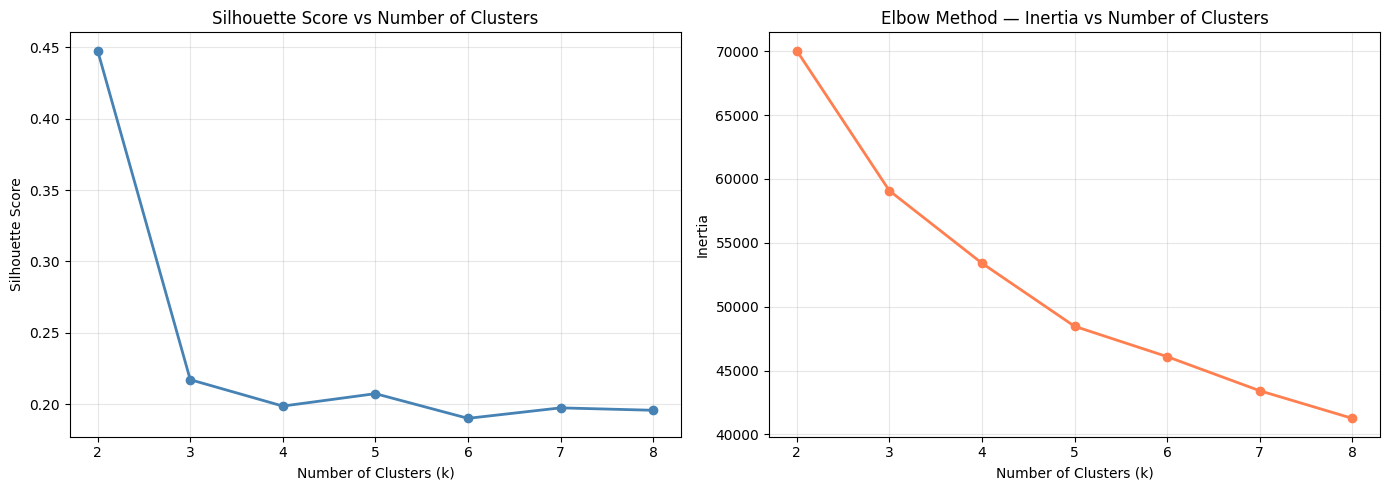

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Silhouette Score plot
axes[0].plot(list(k_range), silhouette_scores, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Silhouette Score vs Number of Clusters')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].grid(True, alpha=0.3)

# Elbow plot
axes[1].plot(list(k_range), inertia_values, marker='o', color='coral', linewidth=2)
axes[1].set_title('Elbow Method — Inertia vs Number of Clusters')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Inertia')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The silhouette score suggested k=2, but a two-class furnishing system loses meaningful market information. Semi-Furnished is a real and distinct category in Indian real estate — properties with basic appliances but no furniture. We accepted a lower silhouette score at k=3 as a deliberate trade-off between statistical optimality and domain relevance. The model still produces interpretable clusters — just with fuzzier boundaries between Furnished and Semi-Furnished

In [63]:
## Step 6 — Fit KMeans with k=3

In [64]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
known_df['furnish_cluster'] = kmeans.fit_predict(scaled_known)

print('Cluster distribution (raw numbers — not yet labelled):')
print(known_df['furnish_cluster'].value_counts())

Cluster distribution (raw numbers — not yet labelled):
furnish_cluster
0    2757
2    1737
1     383
Name: count, dtype: int64


## Step 7 — Interpret Clusters: Which Cluster is Which?
KMeans assigns numbers (0, 1, 2) not labels.
We look at each cluster's centroid total to decide:
highest total = Furnished, middle = Semi-Furnished, lowest = Unfurnished.

In [65]:
cluster_centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=furnishing_items
)
cluster_centroids['total_items'] = cluster_centroids.sum(axis=1)
cluster_centroids.index.name     = 'cluster_id'

print('Cluster centroids sorted by total items:')
cluster_centroids[['total_items']].sort_values('total_items', ascending=False)

Cluster centroids sorted by total items:


,total_items
cluster_id,
1,22.680982
2,5.226382
0,-6.430929


In [66]:
# Build cluster number → furnishing label mapping
cluster_label_map = (
    cluster_centroids['total_items']
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'index': 'cluster_id'})
    .assign(furnishing_type=['Furnished', 'Semi-Furnished', 'Unfurnished'])
    .set_index('cluster_id')['furnishing_type']
    .to_dict()
)

print(f'Cluster to label mapping: {cluster_label_map}')

Cluster to label mapping: {1: 'Furnished', 2: 'Semi-Furnished', 0: 'Unfurnished'}


## Step 8 — Assign Labels
Map cluster numbers to Furnished / Semi-Furnished / Unfurnished labels.

In [67]:
known_df['furnishing_type']   = known_df['furnish_cluster'].map(cluster_label_map)
unknown_df['furnishing_type'] = 'Unfurnished'

print('Known group — furnishing type distribution:')
print(known_df['furnishing_type'].value_counts())
print(f'\nUnknown group — all labelled Unfurnished ({len(unknown_df)} properties)')

Known group — furnishing type distribution:
furnishing_type
Unfurnished       2757
Semi-Furnished    1737
Furnished          383
Name: count, dtype: int64

Unknown group — all labelled Unfurnished (1097 properties)


## Step 9 — Validate: Does the Clustering Make Sense?
Before trusting the labels, verify that:
- Furnished has the highest average item counts
- Unfurnished has the lowest
- The ordering is logical across all 18 items

In [68]:
# Average count of every furnishing item per cluster
# Rows = furnishing type, Columns = each of the 18 items + total
print('Average item counts per furnishing type:')
known_df.groupby('furnishing_type')[furnishing_items + ['total_items']].mean().round(2)

Average item counts per furnishing type:


,Fan,Exhaust Fan,Geyser,Light,Chimney,Wardrobe,AC,Bed,Curtains,Dining Table,Modular Kitchen,Microwave,Fridge,Sofa,Stove,TV,Washing Machine,Water Purifier,total_items
furnishing_type,,,,,,,,,,,,,,,,,,,
Furnished,8.16,0.94,5.11,18.30,0.90,6.14,6.43,4.49,0.99,0.81,0.93,0.83,0.93,0.81,0.85,3.39,0.88,0.91,61.81
Semi-Furnished,8.10,0.97,4.98,22.53,0.93,5.51,5.51,0.09,0.50,0.05,0.98,0.52,0.11,0.01,0.71,0.06,0.07,0.49,52.12
Unfurnished,4.03,0.60,1.51,9.37,0.56,1.93,2.12,0.09,0.19,0.02,0.70,0.05,0.01,0.01,0.08,0.06,0.01,0.05,21.39


In [69]:
# Ordering check — total_items must follow: Furnished > Semi-Furnished > Unfurnished
print('Mean total items per furnishing type (should decrease top to bottom):')
print(
    known_df.groupby('furnishing_type')['total_items']
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

Mean total items per furnishing type (should decrease top to bottom):
furnishing_type
Furnished         61.81
Semi-Furnished    52.12
Unfurnished       21.39
Name: total_items, dtype: float64


In [70]:
# Item presence rate — what % of properties in each cluster have each item?
# More intuitive than raw counts
print('Item presence rate per furnishing type (%):')
(
    known_df.groupby('furnishing_type')[furnishing_items]
    .apply(lambda x: (x > 0).mean() * 100)
    .round(1)
    .T  # items as rows, furnishing type as columns
)

Item presence rate per furnishing type (%):


furnishing_type,Furnished,Semi-Furnished,Unfurnished
Fan,96.9,97.2,74.9
Exhaust Fan,93.7,96.8,59.7
Geyser,93.2,95.7,46.9
Light,96.3,97.5,84.2
Chimney,89.8,93.3,55.7
Wardrobe,94.3,93.0,57.5
AC,95.6,88.1,50.2
Bed,76.8,2.4,3.8
Curtains,85.1,48.2,18.5
Dining Table,81.5,5.4,1.8


In [71]:
for label in ['Furnished', 'Semi-Furnished', 'Unfurnished']:
    print(f'\n=== {label} — Sample Properties ===')
    display(
        known_df[known_df['furnishing_type'] == label]
        [['property_id', 'cleaned_furnishDetails', 'total_items']]
        .head(3)
    )


=== Furnished — Sample Properties ===


,property_id,cleaned_furnishDetails,total_items
38,G75316991,"1 Water Purifier, 5 Fan, 1 Fridge, 1 Exhaust F...",40
46,S83605964,"1 Water Purifier, 3 Fan, 1 Exhaust Fan, 1 Dini...",34
57,V78931763,"1 Water Purifier, 2 Fan, 1 Fridge, 1 Exhaust F...",24



=== Semi-Furnished — Sample Properties ===


,property_id,cleaned_furnishDetails,total_items
0,F84562904,"1 Water Purifier, 6 Fan, 1 Exhaust Fan, 5 Geys...",61
7,C85812490,"3 Wardrobe, 5 Fan, 1 Exhaust Fan, 3 Geyser, 1 ...",41
10,B83901356,"10 Wardrobe, 1 Water Purifier, 15 Fan, 1 Exhau...",75



=== Unfurnished — Sample Properties ===


,property_id,cleaned_furnishDetails,total_items
1,K84166766,"1 Wardrobe, 1 Fan, 1 Light, No AC, No Bed, No ...",3
2,F83288710,"1 Modular Kitchen, 1 Chimney, 8 AC, No Bed, No...",10
5,S83873914,"3 AC, 1 Chimney, 1 Modular Kitchen, No Bed, No...",5


In [72]:
final_df = pd.concat([known_df, unknown_df], axis=0, sort=False)
final_df = final_df[['property_id', 'furnishing_type']]
df       = df.merge(final_df, on='property_id', how='left')

print('Final furnishing_type distribution across full dataset:')
print(df['furnishing_type'].value_counts())
print(f'\nNull values: {df["furnishing_type"].isna().sum()}')

df[['property_id', 'furnishing_details', 'cleaned_furnishDetails', 'furnishing_type']].head(15)

Final furnishing_type distribution across full dataset:
furnishing_type
Unfurnished       3854
Semi-Furnished    1737
Furnished          383
Name: count, dtype: int64

Null values: 0


,property_id,furnishing_details,cleaned_furnishDetails,furnishing_type
0,F84562904,"['1 Water Purifier', '6 Fan', '1 Exhaust Fan',...","1 Water Purifier, 6 Fan, 1 Exhaust Fan, 5 Geys...",Semi-Furnished
1,K84166766,"['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'N...","1 Wardrobe, 1 Fan, 1 Light, No AC, No Bed, No ...",Unfurnished
2,F83288710,"['1 Modular Kitchen', '1 Chimney', '8 AC', 'No...","1 Modular Kitchen, 1 Chimney, 8 AC, No Bed, No...",Unfurnished
3,Q78848665,[],No Info,Unfurnished
4,G81994310,NaN,No Info,Unfurnished
5,S83873914,"['3 AC', '1 Chimney', '1 Modular Kitchen', 'No...","3 AC, 1 Chimney, 1 Modular Kitchen, No Bed, No...",Unfurnished
6,T83786356,"['5 Fan', '1 Exhaust Fan', '10 Light', '1 Chim...","5 Fan, 1 Exhaust Fan, 10 Light, 1 Chimney, 4 A...",Unfurnished
7,C85812490,"['3 Wardrobe', '5 Fan', '1 Exhaust Fan', '3 Ge...","3 Wardrobe, 5 Fan, 1 Exhaust Fan, 3 Geyser, 1 ...",Semi-Furnished
8,J84717004,"['3 Wardrobe', '5 Fan', '1 Exhaust Fan', '2 Ge...","3 Wardrobe, 5 Fan, 1 Exhaust Fan, 2 Geyser, 8 ...",Unfurnished
9,N84980718,NaN,No Info,Unfurnished


In [73]:
df.groupby('furnishing_type').mean(numeric_only=True)

,price_in_cr,price_per_sqft,bedrooms,bathrooms,super_built_up_area,built_up_area,carpet_area,plot_area,study_room,servant_room,store_room,pooja_room,others
furnishing_type,,,,,,,,,,,,,
Furnished,7.905849,38594.328982,5.942559,6.146214,2329.076923,3222.196429,3333.413793,2909.523316,0.475196,0.673629,0.321149,0.511749,0.203655
Semi-Furnished,7.035446,25959.336212,4.257340,4.644214,2657.230769,4150.164384,3199.431655,3191.518591,0.356937,0.783535,0.270006,0.540587,0.165227
Unfurnished,4.311676,22488.442657,3.806694,3.820965,2056.930496,2662.448421,2197.814532,2130.830325,0.224702,0.408407,0.139336,0.270628,0.106383


Furnished properties are genuinely premium:

Average price: ₹7.9 Cr vs ₹4.3 Cr for Unfurnished — 83% more expensive

Price per sqft: ₹38,594 vs ₹22,488 — furnished commands a real premium per sqft

More bedrooms (5.9 vs 3.8) and bathrooms (6.1 vs 3.8)

Semi-Furnished sits correctly in the middle:

Price: ₹7.0 Cr — between Furnished and Unfurnished 

Price per sqft: ₹25,959 — between the two 

Bedrooms and bathrooms also follow the order 

Semi-Furnished has higher built_up and plot area than Furnished :
   
   -  Suggests large independent houses tend to be semi-furnished.

#### 8. Features

In [74]:
fe_df['features'].unique()

array(["['Feng Shui / Vaastu Compliant', 'Water purifier', 'Lift(s)', 'High Ceiling Height', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Visitor Parking', 'Park', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting']",
       nan,
       "['Water purifier', 'Centrally Air Conditioned', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Fitness Centre / GYM', 'Club house / Community C

In [75]:
fe_df['features'].isnull().sum()

np.int64(376)

In [76]:
fe_df['features'].str.strip("[]").str.split("', '")

0       ['Feng Shui / Vaastu Compliant, Water purifier...
1                                                     NaN
2       ['Water purifier, Centrally Air Conditioned, S...
3       ['Feng Shui / Vaastu Compliant, Intercom Facil...
4                                       ['Water Storage']
                              ...                        
5969    ['Water Storage, Recently Renovated, Natural L...
5970    ['Security / Fire Alarm, Feng Shui / Vaastu Co...
5971    ['Water purifier, Centrally Air Conditioned, S...
5972    ['Water purifier, Centrally Air Conditioned, S...
5973    ['Security / Fire Alarm, Feng Shui / Vaastu Co...
Name: features, Length: 5974, dtype: object

In [77]:
fe_df['features'].unique()

array(["['Feng Shui / Vaastu Compliant', 'Water purifier', 'Lift(s)', 'High Ceiling Height', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Visitor Parking', 'Park', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting']",
       nan,
       "['Water purifier', 'Centrally Air Conditioned', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Fitness Centre / GYM', 'Club house / Community C

In [78]:
## Step 1 — Parse Features Column
# The `features` column is stored as a string representation of a list.
# We convert it back to an actual Python list so we can work with it.

df['features_list'] = df['features'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else []
)

# Side by side — raw string vs parsed list
df[['features', 'features_list']].head(10)

,features,features_list
0,"['Feng Shui / Vaastu Compliant', 'Water purifi...","[Feng Shui / Vaastu Compliant, Water purifier,..."
1,NaN,[]
2,"['Water purifier', 'Centrally Air Conditioned'...","[Water purifier, Centrally Air Conditioned, Se..."
3,"['Feng Shui / Vaastu Compliant', 'Intercom Fac...","[Feng Shui / Vaastu Compliant, Intercom Facili..."
4,['Water Storage'],[Water Storage]
5,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...","[Security / Fire Alarm, Feng Shui / Vaastu Com..."
6,"['Feng Shui / Vaastu Compliant', 'Water purifi...","[Feng Shui / Vaastu Compliant, Water purifier,..."
7,"['Feng Shui / Vaastu Compliant', 'Maintenance ...","[Feng Shui / Vaastu Compliant, Maintenance Sta..."
8,"['Security / Fire Alarm', 'Power Back-up', 'Fe...","[Security / Fire Alarm, Power Back-up, Feng Sh..."
9,"['Power Back-up', 'Feng Shui / Vaastu Complian...","[Power Back-up, Feng Shui / Vaastu Compliant, ..."


In [79]:
# How many properties have amenities vs none?

has_amenities = df['features_list'].apply(lambda x: len(x) > 0)

print(f'Properties with amenities    : {has_amenities.sum()}')
print(f'Properties without amenities : {(~has_amenities).sum()}')
print(f'\nAverage amenities per property: {df["features_list"].apply(len).mean():.1f}')
print(f'Max amenities in one property : {df["features_list"].apply(len).max()}')

# What does the distribution look like?
df['features_list'].apply(len).describe().round(2)

Properties with amenities    : 5598
Properties without amenities : 376

Average amenities per property: 15.3
Max amenities in one property : 32


count    5974.00
mean       15.26
std         9.54
min         0.00
25%         8.00
50%        14.00
75%        24.00
max        32.00
Name: features_list, dtype: float64

In [80]:
# What are the most common amenities overall?
from collections import Counter

all_amenities = [amenity for lst in df['features_list'] for amenity in lst]
amenity_counts = pd.Series(Counter(all_amenities)).sort_values(ascending=False)

print(f'Total unique amenities: {len(amenity_counts)}')
print('\nTop 20 most common amenities:')
print(amenity_counts.head(20))

Total unique amenities: 32

Top 20 most common amenities:
Park                               4723
Maintenance Staff                  4404
Visitor Parking                    4385
Water Storage                      4362
Feng Shui / Vaastu Compliant       4148
Rain Water Harvesting              4009
Waste Disposal                     3564
Club house / Community Center      3523
Fitness Centre / GYM               3490
Swimming Pool                      3191
Lift(s)                            3095
Natural Light                      2986
Security Personnel                 2947
Security / Fire Alarm              2887
No open drainage around            2811
High Ceiling Height                2716
Airy Rooms                         2711
Intercom Facility                  2664
Piped-gas                          2645
Separate entry for servant room    2463
dtype: int64


## Step 2 — Multi-Hot Encode Amenities
Convert the list of amenities per property into a binary matrix.
Each column = one amenity. Value = 1 if present, 0 if not.
This is called multi-hot encoding (like one-hot but multiple 1s per row).

In [81]:
mlb             = MultiLabelBinarizer()
binary_features = mlb.fit_transform(df['features_list'])

features_encoded = pd.DataFrame(
    binary_features,
    columns=mlb.classes_,
    index=df.index
)

print(f'Encoded matrix shape: {features_encoded.shape}')
print(f'Rows = properties, Columns = unique amenities')
features_encoded.head(10)

Encoded matrix shape: (5974, 32)
Rows = properties, Columns = unique amenities


,Airy Rooms,Bank Attached Property,Centrally Air Conditioned,Club house / Community Center,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fitness Centre / GYM,High Ceiling Height,Intercom Facility,Internet/wi-fi connectivity,...,Security Personnel,Separate entry for servant room,Shopping Centre,Spacious Interiors,Swimming Pool,Visitor Parking,Waste Disposal,Water Storage,Water purifier,Water softening plant
0,1,1,0,0,1,1,0,1,0,0,...,0,1,0,1,0,1,1,1,1,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,1,1,1,1,1,0,1,...,1,1,0,1,1,1,1,1,1,0
3,0,0,0,1,0,1,1,0,1,1,...,1,0,1,0,1,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
5,1,0,0,1,0,1,1,0,1,0,...,1,0,1,1,1,1,1,1,0,1
6,0,1,1,1,1,1,1,1,0,1,...,1,0,0,0,1,1,1,1,1,0
7,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
8,1,1,0,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,0,1
9,0,0,0,1,0,1,1,0,1,0,...,0,0,1,0,0,1,0,1,0,0


In [82]:
# How many amenities does each property have?
amenity_count_per_property = features_encoded.sum(axis=1)

print('Amenities per property:')
print(amenity_count_per_property.describe().round(2))

# How many properties have each amenity?
amenity_count_per_column = features_encoded.sum(axis=0).sort_values(ascending=False)
print('\nTop 10 most present amenities (by property count):')
print(amenity_count_per_column.head(10))
print('\nBottom 10 rarest amenities:')
print(amenity_count_per_column.tail(10))

Amenities per property:
count    5974.00
mean       15.26
std         9.54
min         0.00
25%         8.00
50%        14.00
75%        24.00
max        32.00
dtype: float64

Top 10 most present amenities (by property count):
Park                             4723
Maintenance Staff                4404
Visitor Parking                  4385
Water Storage                    4362
Feng Shui / Vaastu Compliant     4148
Rain Water Harvesting            4009
Waste Disposal                   3564
Club house / Community Center    3523
Fitness Centre / GYM             3490
Swimming Pool                    3191
dtype: int64

Bottom 10 rarest amenities:
Spacious Interiors             2378
Internet/wi-fi connectivity    2253
Private Garden / Terrace       2245
Water purifier                 2176
Shopping Centre                1881
Recently Renovated             1707
Bank Attached Property         1557
Centrally Air Conditioned      1538
Power Back-up                  1472
Water softening plant      

## Step 3 — Compute Price Premium Per Amenity
For each amenity, we compare:
- Median price_per_sqft of properties that HAVE the amenity
- Median price_per_sqft of properties that DON'T have the amenity

The difference = pricing premium that amenity commands.
Amenities with fewer than 30 properties are ignored — too rare to be statistically reliable.
Negative premiums are capped at 0 — we only reward, never penalise.

In [83]:
amenity_weights  = {}
amenity_details  = []   # for inspection
MIN_PROPERTIES   = 30   # minimum properties needed for reliable premium calculation

for col in features_encoded.columns:
    present_mask = features_encoded[col] == 1
    absent_mask  = features_encoded[col] == 0

    if present_mask.sum() > MIN_PROPERTIES:
        median_present = df.loc[present_mask, 'price_per_sqft'].median()
        median_absent  = df.loc[absent_mask,  'price_per_sqft'].median()
        premium        = median_present - median_absent

        amenity_weights[col] = max(premium, 0)
        amenity_details.append({
            'amenity'       : col,
            'properties_with': present_mask.sum(),
            'median_with'   : round(median_present, 0),
            'median_without': round(median_absent, 0),
            'premium'       : round(premium, 0),
            'weight'        : round(max(premium, 0), 0)
        })
    else:
        amenity_weights[col] = 0

amenity_details_df = pd.DataFrame(amenity_details).sort_values('premium', ascending=False)

print(f'Amenities with enough data (>30 properties): {len(amenity_details_df)}')
print(f'Amenities ignored (too rare)               : {len(features_encoded.columns) - len(amenity_details_df)}')
print('\nTop 15 amenities by price premium (₹/sqft):')
amenity_details_df.head(15)

Amenities with enough data (>30 properties): 32
Amenities ignored (too rare)               : 0

Top 15 amenities by price premium (₹/sqft):


,amenity,properties_with,median_with,median_without,premium,weight
18,Private Garden / Terrace,2245,20300.0,15000.0,5300.0,5300.0
20,Recently Renovated,1707,18095.0,15678.0,2417.0,2417.0
28,Waste Disposal,3564,16885.0,15410.0,1474.0,1474.0
11,Low Density Society,2443,16917.0,15740.0,1177.0,1177.0
23,Separate entry for servant room,2463,16703.0,15920.0,783.0,783.0
0,Airy Rooms,2711,16666.0,15889.0,777.0,777.0
2,Centrally Air Conditioned,1538,16793.0,16029.0,764.0,764.0
29,Water Storage,4362,16472.0,15750.0,721.0,721.0
4,False Ceiling Lighting,2448,16678.0,15983.0,696.0,696.0
13,Natural Light,2986,16474.0,16022.0,452.0,452.0


In [84]:
# Amenities with negative premium — capped to 0
# These amenities are present in cheaper properties — not luxury signals
print('Amenities with NEGATIVE premium (these get weight = 0):')
amenity_details_df[amenity_details_df['premium'] < 0][['amenity', 'premium']]

Amenities with NEGATIVE premium (these get weight = 0):


,amenity,premium
25,Spacious Interiors,-40.0
19,Rain Water Harvesting,-126.0
27,Visitor Parking,-374.0
22,Security Personnel,-658.0
1,Bank Attached Property,-792.0
5,Feng Shui / Vaastu Compliant,-1076.0
16,Piped-gas,-1234.0
12,Maintenance Staff,-1602.0
31,Water softening plant,-1990.0
21,Security / Fire Alarm,-2306.0


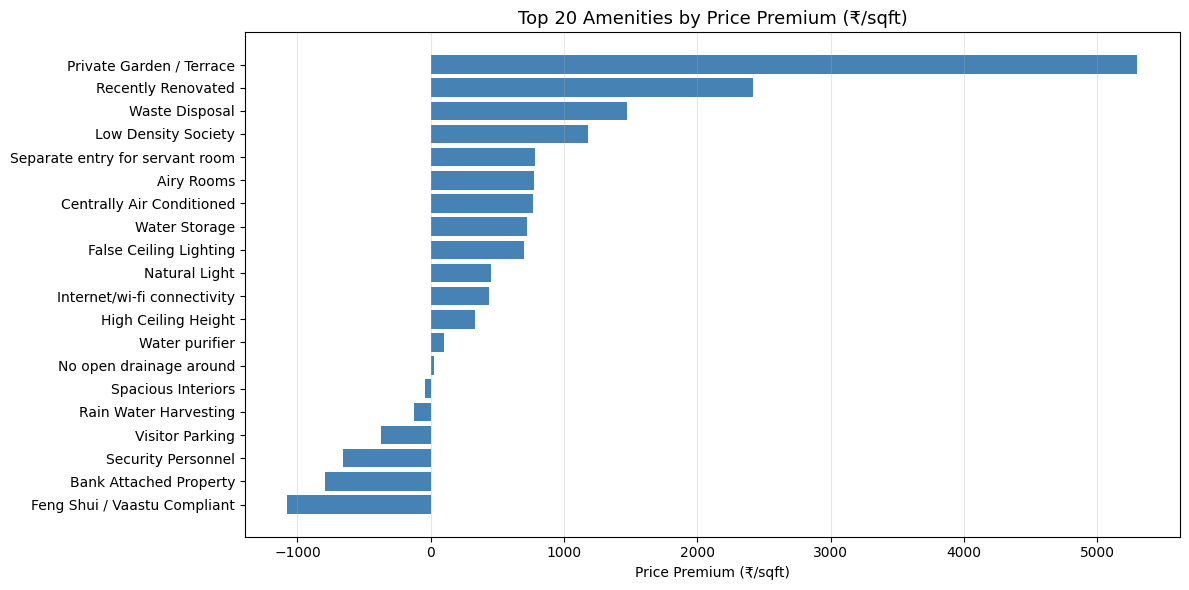

In [85]:
# Visualize top 20 amenities by raw premium
top20 = amenity_details_df.head(20)

plt.figure(figsize=(12, 6))
plt.barh(top20['amenity'][::-1], top20['premium'][::-1], color='steelblue')
plt.title('Top 20 Amenities by Price Premium (₹/sqft)', fontsize=13)
plt.xlabel('Price Premium (₹/sqft)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4 — Normalize Weights to 0–1 Range
Raw premiums are in ₹/sqft — they vary widely.
We normalize so the highest premium amenity gets weight = 1.0
and all others get a proportional weight between 0 and 1.

In [86]:
weights_series = pd.Series(amenity_weights)

# Before normalization
print('Before normalization:')
print(f'Min weight : {weights_series.min():.2f}')
print(f'Max weight : {weights_series.max():.2f}')
print(f'Mean weight: {weights_series.mean():.2f}')

# Normalize
if weights_series.max() > 0:
    weights_series = weights_series / weights_series.max()

print('\nAfter normalization:')
print(f'Min weight : {weights_series.min():.4f}')
print(f'Max weight : {weights_series.max():.4f}')
print(f'Mean weight: {weights_series.mean():.4f}')

print('\nTop 10 highest weighted amenities:')
weights_series.sort_values(ascending=False).head(10)

Before normalization:
Min weight : 0.00
Max weight : 5300.00
Mean weight: 482.86

After normalization:
Min weight : 0.0000
Max weight : 1.0000
Mean weight: 0.0911

Top 10 highest weighted amenities:


Private Garden / Terrace           1.000000
Recently Renovated                 0.456038
Waste Disposal                     0.278208
Low Density Society                0.222075
Separate entry for servant room    0.147736
Airy Rooms                         0.146604
Centrally Air Conditioned          0.144151
Water Storage                      0.136038
False Ceiling Lighting             0.131226
Natural Light                      0.085283
dtype: float64

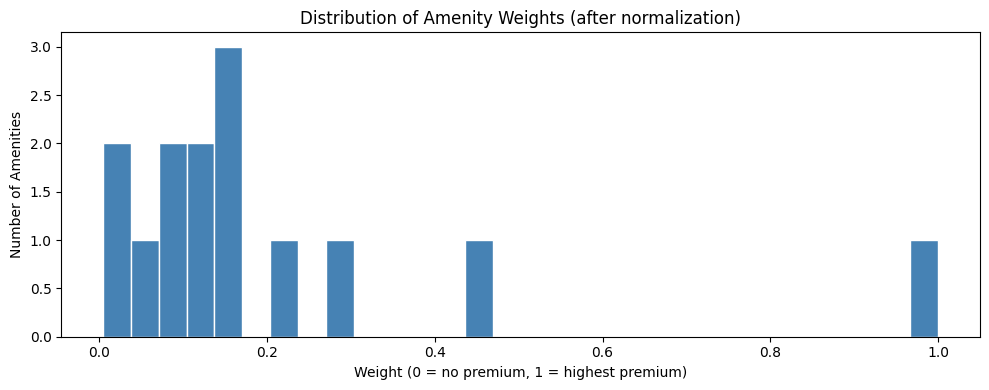

In [87]:
# Distribution of weights
plt.figure(figsize=(10, 4))
weights_series[weights_series > 0].hist(bins=30, color='steelblue', edgecolor='white')
plt.title('Distribution of Amenity Weights (after normalization)')
plt.xlabel('Weight (0 = no premium, 1 = highest premium)')
plt.ylabel('Number of Amenities')
plt.grid(False)
plt.tight_layout()
plt.show()

## Step 5 — Compute Final Luxury Score
For each property:
1. Multiply each amenity binary (0/1) by its normalized weight
2. Sum across all amenities → raw weighted score
3. Apply log1p → reduces skew from properties with many amenities

log1p(x) = log(1 + x) — compresses large values while keeping small ones meaningful.

In [88]:
# Raw weighted score (before log)
raw_score = features_encoded.mul(weights_series, axis=1).sum(axis=1)

print('Raw weighted score distribution (before log1p):')
print(raw_score.describe().round(4))

Raw weighted score distribution (before log1p):
count    5974.0000
mean        1.1915
std         1.0235
min         0.0000
25%         0.1518
50%         1.0043
75%         2.0208
max         2.9154
dtype: float64


In [89]:
# Apply log1p
df['luxury_score'] = np.log1p(raw_score)

print('Luxury score distribution (after log1p):')
print(df['luxury_score'].describe().round(4))

Luxury score distribution (after log1p):
count    5974.0000
mean        0.6718
std         0.4801
min         0.0000
25%         0.1413
50%         0.6953
75%         1.1055
max         1.3649
Name: luxury_score, dtype: float64


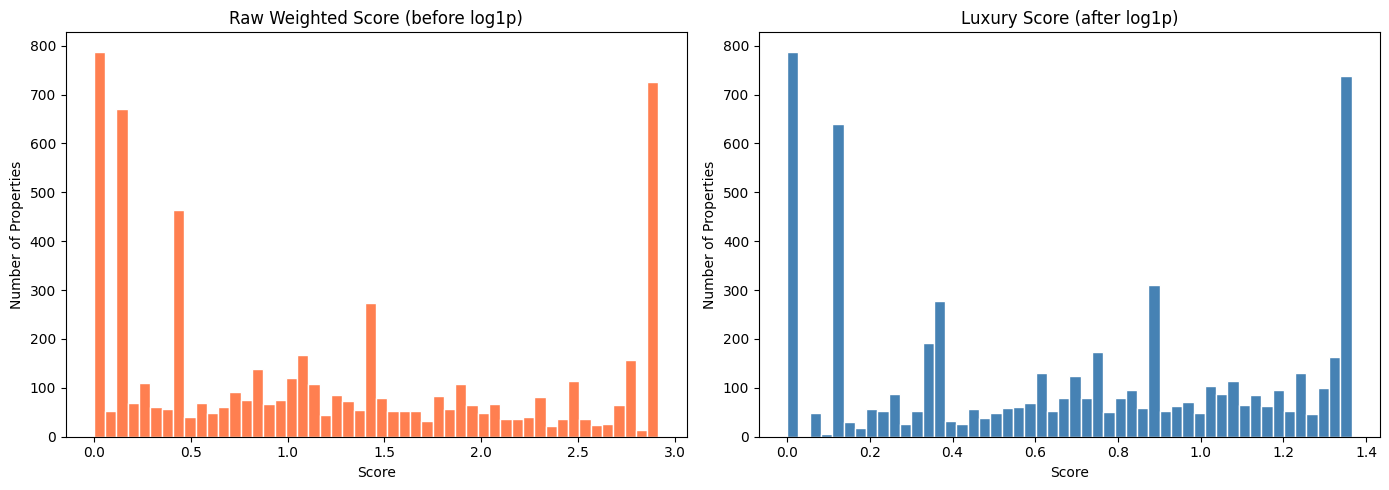

In [90]:
# Why log1p? — visualize raw vs log score distributions side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(raw_score, bins=50, color='coral', edgecolor='white')
axes[0].set_title('Raw Weighted Score (before log1p)')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Number of Properties')
axes[0].grid(False)

axes[1].hist(df['luxury_score'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Luxury Score (after log1p)')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Number of Properties')
axes[1].grid(False)

plt.tight_layout()
plt.show()


## Step 6 — Validate: Does the Luxury Score Make Sense?
A good luxury score should correlate with price. Higher score = higher price.

In [91]:
# Correlation between luxury score and price
corr_price     = df['luxury_score'].corr(df['price_in_cr'])
corr_ppsf      = df['luxury_score'].corr(df['price_per_sqft'])

print(f'Correlation — luxury score vs price_in_cr    : {corr_price:.4f}')
print(f'Correlation — luxury score vs price_per_sqft : {corr_ppsf:.4f}')
print('\nExpected: positive correlation — higher score = higher price')

Correlation — luxury score vs price_in_cr    : 0.2585
Correlation — luxury score vs price_per_sqft : 0.0653

Expected: positive correlation — higher score = higher price


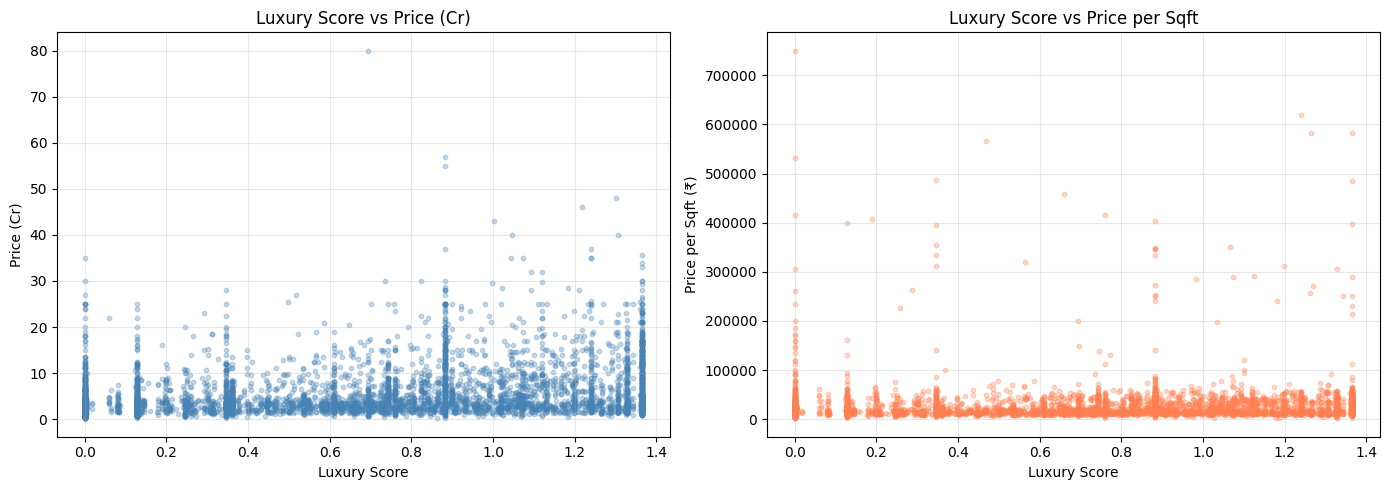

In [92]:
# Scatter plot — luxury score vs price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['luxury_score'], df['price_in_cr'], alpha=0.3, color='steelblue', s=10)
axes[0].set_title('Luxury Score vs Price (Cr)')
axes[0].set_xlabel('Luxury Score')
axes[0].set_ylabel('Price (Cr)')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df['luxury_score'], df['price_per_sqft'], alpha=0.3, color='coral', s=10)
axes[1].set_title('Luxury Score vs Price per Sqft')
axes[1].set_xlabel('Luxury Score')
axes[1].set_ylabel('Price per Sqft (₹)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [93]:
# Bucket luxury score into 3 bands and compare average prices
# This is the clearest validation — do higher score buckets = higher prices?
df['score_bucket'] = pd.qcut(
    df['luxury_score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

print('Average price per luxury score bucket:')
df.groupby('score_bucket')[['price_in_cr', 'price_per_sqft']].mean().round(2)

Average price per luxury score bucket:


C:\Users\Jay Patel\AppData\Local\Temp\ipykernel_2012\752983925.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('score_bucket')[['price_in_cr', 'price_per_sqft']].mean().round(2)


,price_in_cr,price_per_sqft
score_bucket,,
Low,3.80,22537.83
Medium,5.48,24590.80
High,6.73,26461.02


In [94]:
# Spot check — top 5 highest scoring properties
print('Top 5 highest luxury score properties:')
display(
    df.nlargest(5, 'luxury_score')
    [['property_id', 'luxury_score', 'price_in_cr', 'price_per_sqft', 'features']]
)

print('\nBottom 5 lowest luxury score properties:')
display(
    df.nsmallest(5, 'luxury_score')
    [['property_id', 'luxury_score', 'price_in_cr', 'price_per_sqft', 'features']]
)

Top 5 highest luxury score properties:


,property_id,luxury_score,price_in_cr,price_per_sqft,features
2,F83288710,1.364912,8.5,18888,"['Water purifier', 'Centrally Air Conditioned'..."
10,B83901356,1.364912,15.0,33333,"['Centrally Air Conditioned', 'Water purifier'..."
19,A84316644,1.364912,9.4,48579,"['Security / Fire Alarm', 'Feng Shui / Vaastu ..."
27,T84362422,1.364912,1.6,10709,"['Centrally Air Conditioned', 'Water purifier'..."
38,G75316991,1.364912,8.5,18888,"['Centrally Air Conditioned', 'Water purifier'..."



Bottom 5 lowest luxury score properties:


,property_id,luxury_score,price_in_cr,price_per_sqft,features
1,K84166766,0.0,0.75,4167,NaN
7,C85812490,0.0,2.80,15512,"['Feng Shui / Vaastu Compliant', 'Maintenance ..."
16,J68899930,0.0,1.65,13200,"['Feng Shui / Vaastu Compliant', 'Lift(s)', 'S..."
21,P83934036,0.0,7.20,66667,NaN
25,R84594132,0.0,3.11,15534,"['Power Back-up', 'Intercom Facility', 'Lift(s..."


In [95]:
# Properties with zero luxury score — no amenities at all?
zero_score = df[df['luxury_score'] == 0]
print(f'Properties with luxury_score = 0 : {len(zero_score)}')
print(f'Do they have empty features list? : {(zero_score["features_list"].apply(len) == 0).sum()} properties')
zero_score[['property_id', 'features', 'price_in_cr']].head(5)

Properties with luxury_score = 0 : 777
Do they have empty features list? : 376 properties


,property_id,features,price_in_cr
1,K84166766,NaN,0.75
7,C85812490,"['Feng Shui / Vaastu Compliant', 'Maintenance ...",2.80
16,J68899930,"['Feng Shui / Vaastu Compliant', 'Lift(s)', 'S...",1.65
21,P83934036,NaN,7.20
25,R84594132,"['Power Back-up', 'Intercom Facility', 'Lift(s...",3.11


In [96]:
fe_df

,property_name,society,price_in_cr,price_per_sqft,areawithtype,property_id,link,bedrooms,bathrooms,balcony,...,super_built_up_area,built_up_area,carpet_area,plot_area,study_room,servant_room,store_room,pooja_room,others,age_possession_category
0,4 BHK Independent Builder Floor in Sushant Lok...,"sushant lok phase 1, gurgaon",3.75,13883,"2,701 sqft (251 sqm) Super Built-up Area",F84562904,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,2701.0,NaN,NaN,NaN,0,1,0,0,1,New Property
1,"5 Bedroom House in Sohna Road, Gurgaon","sohna road, gurgaon",0.75,4167,1800 sqft (167.23 sqm) Built-up Area,K84166766,https://www.99acres.com/5-bhk-bedroom-independ...,5,3,0,...,NaN,1800.0,NaN,NaN,0,0,0,0,0,Undefined
2,"4 Bedroom House in Sector 72, Gurgaon",tata primanti,8.50,18888,4500 sqft (418.06 sqm) Plot Area,F83288710,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,3+,...,NaN,NaN,NaN,4500.0,0,1,0,0,0,Relatively New
3,"3 BHK Flat in DLF Phase 4, Gurgaon",dlf ridgewood estate,2.95,21532,"1,370 sqft (127 sqm) Super Built-up Area",Q78848665,https://www.99acres.com/3-bhk-bedroom-apartmen...,3,3,1,...,1370.0,NaN,NaN,NaN,0,0,0,0,0,Old Property
4,"3 Bedroom House in Behrampur, Gurgaon","behrampur, gurgaon",0.41,3927,1044 sqft (96.99 sqm) Plot Area,G81994310,https://www.99acres.com/3-bhk-bedroom-independ...,3,2,2,...,NaN,NaN,NaN,1044.0,0,0,0,0,0,Relatively New
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,"6 Bedroom House in Sector 46, Gurgaon","sector 46, gurgaon",5.15,35542,1449 sqft (134.62 sqm) Plot Area,A84830038,https://www.99acres.com/6-bhk-bedroom-independ...,6,6,2,...,NaN,NaN,NaN,1449.0,0,0,0,1,0,Old Property
5970,5 BHK Independent Builder Floor in DLF Phase 1...,dlf phase 1 ultra luxury builder floors,8.75,15909,"5,500 sqft (511 sqm) Carpet Area",V85221106,https://www.99acres.com/5-bhk-bedroom-independ...,5,6,2,...,NaN,NaN,5500.0,NaN,1,1,1,1,0,Relatively New
5971,4 BHK Independent Builder Floor in DLF Phase 2...,dlf luxury builder floors,5.55,14605,"3,800 sqft (353 sqm) Carpet Area",I85247572,https://www.99acres.com/4-bhk-bedroom-independ...,4,5,2,...,NaN,NaN,3800.0,NaN,1,1,0,1,1,New Property
5972,"4 BHK Independent Builder Floor in Sector 67, ...",ansal api esencia,2.61,12253,"2,430 sqft (226 sqm) Super Built-up Area",A84042908,https://www.99acres.com/4-bhk-bedroom-independ...,4,4,2,...,2430.0,NaN,NaN,NaN,0,1,0,1,1,Relatively New


In [97]:
fe_df.to_csv(r"..\..\data\analytics_module\wordcloud.csv",index= False)